# 04 — Exploratory Data Analysis

**Project:** Predicting Corporate GHG Intensity  
**Purpose:** Explore distributions, trends, and correlations in the linked dataset.

---


In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"

### 1. Load Linked Panel

In [2]:
df = pd.read_csv(INTERIM_DIR / "linked_panel.csv")
df_reporting = df[df["selected"] == 1].copy()
df_reporting["scope1_intensity_rev"] = df_reporting["scope1_emissions"] / df_reporting["revenue"].replace(0, 1)
print(f"Reporting firm-years: {len(df_reporting)}")

Reporting firm-years: 1784


### 2. Visualize Target Variable Distribution
Corporate GHG intensity is typically highly right-skewed.

E:\Research_Projects\predicting-corporate-ghg-intensity\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


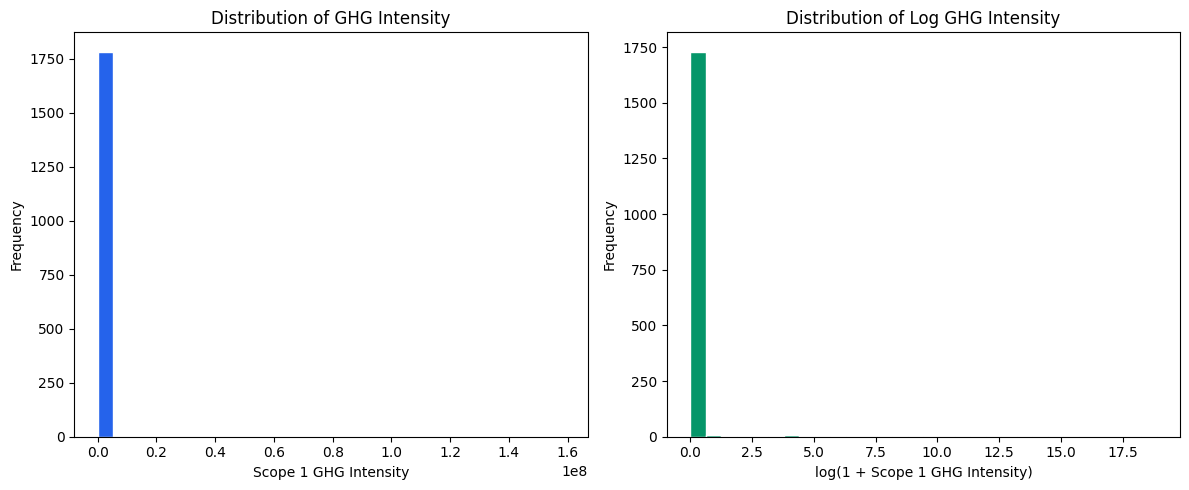

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(df_reporting["scope1_intensity_rev"].dropna(), bins=30, color="#2563EB", edgecolor="white")
ax[0].set_xlabel("Scope 1 GHG Intensity")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Distribution of GHG Intensity")

import numpy as np
ax[1].hist(np.log1p(df_reporting["scope1_intensity_rev"].dropna()), bins=30, color="#059669", edgecolor="white")
ax[1].set_xlabel("log(1 + Scope 1 GHG Intensity)")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Distribution of Log GHG Intensity")
plt.tight_layout()
plt.show()

### 3. Sector Distribution
We inspect representation across sectors.

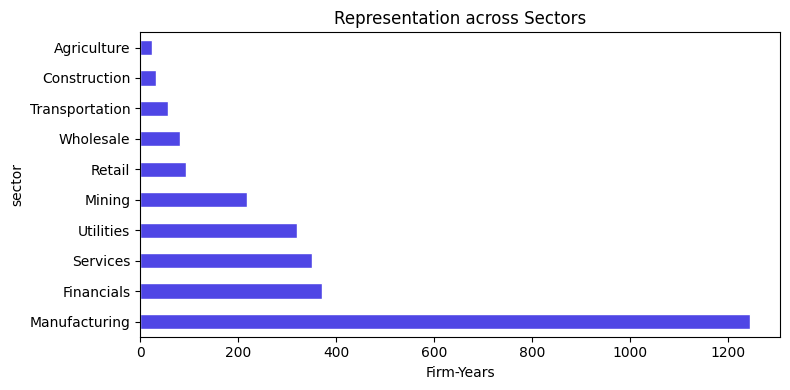

In [4]:
sector_counts = df["sector"].value_counts()
plt.figure(figsize=(8, 4))
sector_counts.plot(kind="barh", color="#4F46E5", edgecolor="white")
plt.xlabel("Firm-Years")
plt.title("Representation across Sectors")
plt.tight_layout()
plt.show()

### Discussion & Next Steps
The plots confirm high right-skewness in raw GHG intensity, suggesting that log-transformations or industry-adjusted z-scores are appropriate modeling targets. In the next notebook, we construct financial features and compute the Heckman Inverse Mills Ratio.